In [ ]:
# The code below produces a plot of the Continuous Dual Hahn Poisson flow as described in the paper:
# "Visualising the flows of orthogonal polynomial expansions of the Riemann Xi-function".
# The program reads the file with pre-computed coefficients and produces an implicit plot, 
# i.e. it visualises the flow of the real roots when r varies. 
# Version 1.0, December 22, 2025. 

In [361]:
%%gp
default(realprecision, 150)
Phi(u) = 2*sum(n=1, 12, (2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
AppellF3(x,n,a,b,c) = sum(m=0,50, gamma(n+m+a+b)*gamma(1/2-c+m)*gamma(n+1/2)/(gamma(n+a+b)*gamma(1/2-c)*gamma(n+m+1/2)*gamma(m+1)) *tanh(x/2)^(2*m)*hypergeom([-b,-a],[m+n+1/2],-sinh(x/2)^2))
tes(n,a,b,c) = 2^(2*n+1) / gamma(2*n+1) * intnum(x=0,3, Phi(x) * tanh(x/2)^(2*n) * cosh(x/2)^(-2*(a+b))*AppellF3(x, n, a, b, c))
for(n=0,201, printf("%1.120e \n", tes(n,22.209,22.209,22.209)))


(u)->2*sum(n=1,12,(2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
(x,n,a,b,c)->sum(m=0,50,gamma(n+m+a+b)*gamma(1/2-c+m)*gamma(n+1/2)/(gamma(n+a+b)*gamma(1/2-c)*gamma(n+m+1/2)*gamma(m+1))*tanh(x/2)^(2*m)*hypergeom([-b,-a],[m+n+1/2],-sinh(x/2)^2))
(n,a,b,c)->2^(2*n+1)/gamma(2*n+1)*intnum(x=0,3,Phi(x)*tanh(x/2)^(2*n)*cosh(x/2)^(-2*(a+b))*AppellF3(x,n,a,b,c))
-1.854409433179139488504258264511812186951933491217075848910118708505303101814542570411526548487090293257757821396424932925 e-9 
-1.336396849458223013124702246084979560786621967984588069505146048978922066909344059015546488807026610323895013544980680760 e-11 
-4.759921996182193199582129879906681855969165637341410283006315874203084029382121055942838511234524591088890443785958609895 e-14 
-1.088584517053545649204516471725469541987195575614546392017870387069154724268002130145000003878042856772795137864933327422 e-16 
-1.7257521663687476888038074060888759498226244363774950880751153137573715067857688110576014079529713803

In [360]:
#Generate coefficients for Continuous Dual Hahn for flow of Xi for a, b, c.
var("r", "t", "y");

CCF=ComplexBallField(624)
RDF=RealBallField(624)

#Select the desired parametes a and b here
global a, b, c
a = CCF("22.209")
b = CCF("22.209")
c = CCF("22.209")

global half
half = CCF("0.5")

# Generate and store the coefficients for the choice of a, b, c

def Phi(x, N):
    termexp2x=-1*RDF(pi)*RDF(2*x).exp()
    termexp5x= 6*RDF(pi)*RDF(5*x/2).exp()
    termexp9x= 4*RDF(pi)*RDF(pi)*CCF(9*x/2).exp()
    sum=(RDF(0))
    for n in range(N):
        summand =  ((n+1)^4*termexp9x-(n+1)^2*termexp5x)*((n+1)^2*termexp2x).exp()   
        sum = sum + summand
    return sum

def PH(z, n):
    return (z + n).gamma() / (z).gamma()

def hyp2F1(a1, a2, b1, y):
    return  CCF(y).hypergeometric([a1, a2],[b1])

def AppellF3(n, x):
    msum = 0
    for m in range(30):
        mr = RDF(m)
        summ = PH(a + b + n, mr) * PH(half - c, mr) / ((mr + 1).gamma() * PH(n + half, mr)) * (CCF(x/2).tanh()).pow(2 * mr) * hyp2F1(-b, -a, mr + n + half, -1*(CCF(x/2).sinh()).pow(2))
        msum = msum + summ
    return msum

def integrand(n, x):
    term1 = (CCF(x/2).tanh()).pow(2 * n) * (CCF(x/2).sech()).pow(2 * a + 2 * b)
    integr = term1 * Phi(x.abs(), 6) * AppellF3(n, x)
    return integr 

def CDHcoeff(n):
    pre = CCF(2).pow(2 * n + 1) / CCF(2 * n + 1).gamma()
    res =  pre * CCF.integral(lambda y, _: integrand(n, y), CCF("0"), 2)
    return real_part(res)

print("Computing 200 coefficients...")

global m1; m1 = [];
for n in range(201):
    Coe = CDHcoeff(n)
    print(Coe)
    m1.append([Coe]) 

print("Done!")

Computing 200 coefficients...
[-1.854409433182349975141052343930298176459587544410385377780737190543757204194274425516290261856440824364010240022424935157286628914928830625321116335847296342359536205375040e-9 +/- 5.82e-181]


KeyboardInterrupt: 

Automated checks:
The sum of all the coefficients is   : 4691.5968721017998178 = Xi(ai) = 4691.5968721017998178 (should be equal).
d/dr z_3(0) via Newton approximation : 0.013398 versus formula: -0.022403 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


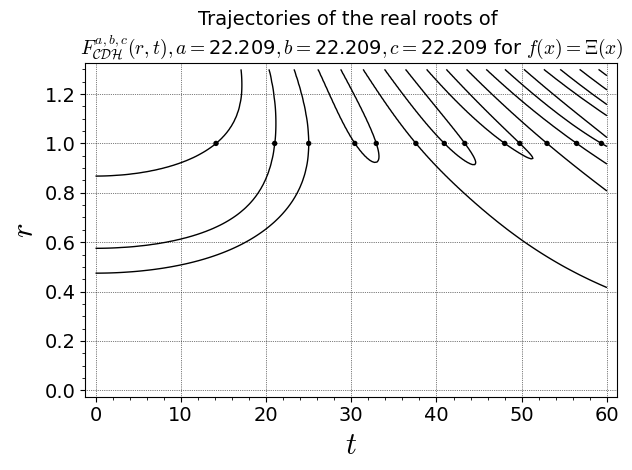

In [369]:
#Continuous Dual Hahn for flow of Xi for a, b, c using pre-computed coefficients.
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Select the desired parameters a,b and c here
global a, b, c
a = CCF("22.209")
b = CCF("22.209")
c = CCF("22.209")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')
cst = str(c.mid()); cstr = cst.rstrip('0')

global half
half = CCF("0.5")

global m1; m1 = []; CoeffSum = RDF(0)
n = 0
with open("ContDualHahnCoeffa22d209b22d209c22d209New", "r") as f:
    for row in f:
        Coe = RDF(row)
        CoeffSum = CoeffSum + (a + b + n).gamma() * (a + c + n).gamma()  / ((a + b).gamma() * (a + c).gamma()) * Coe
        m1.append([RDF(row)])
        n = n + 1

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def ContDualHahnPoly(t, n):
    pre = (a + b + n).gamma() * (a + c + n).gamma()  / ((a + b).gamma() * (a + c).gamma())
    f1  =  CCF(a,0) + I*CCF(t); f2 = CCF(a,0) - I*CCF(t)
    CDHpol = pre * CCF(1).hypergeometric([-n, f1, f2],[a + b, a + c])
    return CDHpol

def ContDualHahnFlow(t,rho):
    sum=CCF(0)
    for n in range(200):
        g = CCF(rho)
        sum=sum+g.pow(n)*CCF(str(m1[n]))*ContDualHahnPoly(t, n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(ContDualHahnFlow(x0 + tr*100,1+tr) - ContDualHahnFlow(x0,1+tr)) / (tr*100)
        h = RDF(ContDualHahnFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)*(c.mid()-I*x)/(2*I*x*(2*I*x-1))

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)*(c.mid()+I*x)/(2*I*x*(2*I*x+1))

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1])*prodzeros(k,I) + D(ordrho[k-1])*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), ContDualHahnFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(ContDualHahnFlow(60,1)-Xi(60).mid()))

a1 =implicit_plot(lambda t,r:RDF(ContDualHahnFlow(t,r)),(t,0,60),(r,0,1.3),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b,c}_{\mathcal{CDH}}(r,t), a=$' + astr + r'$, b=$'+ bstr + r'$, c=$'+ cstr +' for $f(x)=\Xi(x)$',gridlines=True,plot_points=210)
show(a1 + z,aspect_ratio='automatic')

Computing 200 coefficients...
Done!
Preparing plot...
Automated checks:
The sum of all the coefficients is   : 27.9950048468757409 = Xin(ai) = 27.9950048468757409 (should be equal).
d/dr z_3(0) via Newton approximation : 0.000932 versus formula: 0.000932 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


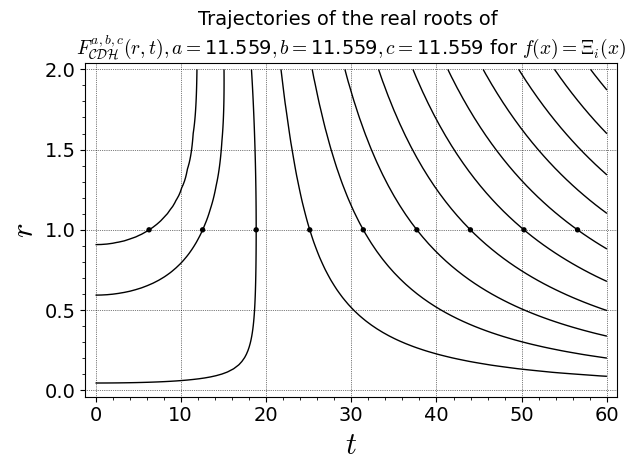

In [367]:
#Continuous Dual Hahn for flow of Xi_i for a, b, c.
var("r", "t", "y");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Select the desired parameters a,b and c here
global a, b, c, N
a = CCF("11.559")
b = CCF("11.559")
c = CCF("11.559")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')
cst = str(c.mid()); cstr = cst.rstrip('0')

N = 200

global half
half = CCF("0.5")

# Generate and store the coefficients for the choice of a, b, c

def PH(z, n):
    return (z + n).gamma() / (z).gamma()

def hyp2F1(a1, a2, b1, y):
    return  CCF(y).hypergeometric([a1, a2],[b1])

def AppellF3(n, x):
    msum = 0
    for m in range(30):
        mr = RDF(m)
        summ = PH(a + b + n, mr) * PH(half - c, mr) / ((mr + 1).gamma() * PH(n + half, mr)) * (x).pow(2 * mr) * hyp2F1(-b, -a, mr + n + half, x.pow(2)/(x.pow(2)-1))
        msum = msum + summ
    return msum

def integrand(n, x):
    term1 = CCF(x).pow(2 * n) * CCF(1 -  x.pow(2)).pow(a + b - 1)
    integr = term1 * AppellF3(n, x)
    return integr 

def CDHcoeff(n):
    pre = CCF(2).pow(2 * n + 2) / CCF(2 * n + 1).gamma()
    res =  pre * CCF.integral(lambda y, _: integrand(n, y), CCF("0.00000000000000000000001"), CCF("0.25").tanh())
    return real_part(res)

print("Computing 200 coefficients...")

global m1; m1 = [];
CoeffSum = CCF("0")
for n in range(N):
    Coe = CDHcoeff(n)
    CoeffSum = CoeffSum + (a + b + n).gamma() * (a + c + n).gamma()  / ((a + b).gamma() * (a + c).gamma()) * Coe
    m1.append([Coe]) 

print("Done!")
print("Preparing plot...")

# Make the plot based on the coefficients for a and b

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def ContDualHahnPoly(t, n):
    pre = (a + b + n).gamma() * (a + c + n).gamma()  / ((a + b).gamma() * (a + c).gamma())
    f1  =  CCF(a,0) + I*CCF(t); f2 = CCF(a,0) - I*CCF(t)
    CDHpol = pre * CCF(1).hypergeometric([-n, f1, f2],[a + b, a + c])
    return CDHpol

def ContDualHahnFlow(t,rho):
    sum=CCF(0)
    for n in range(N):
        g = CCF(rho)
        sum=sum+g.pow(n)*CCF(str(m1[n]))*ContDualHahnPoly(t, n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(ContDualHahnFlow(x0 + tr*100,1+tr) - ContDualHahnFlow(x0,1+tr)) / (tr*100)
        h = RDF(ContDualHahnFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)*(c.mid()-I*x)/(2*I*x*(2*I*x-1))

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)*(c.mid()+I*x)/(2*I*x*(2*I*x+1))

#closed form for sum of zeros around k-th zero
def ZS(k,z):
    zk =CCF(2*pi()*k)
    return 2*zk*CCF(z/2).sin()/(zk + z)   

#compute d/dr zk via formula
def verifyDDE(k):
    return B(2 * pi() * k)*ZS(k,I) + D(2 * pi() * k)*ZS(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xin(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), ContDualHahnFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(ContDualHahnFlow(60,1)-Xin(60).mid()))

a1i=implicit_plot(lambda t,r:RDF(ContDualHahnFlow(t,r)),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b,c}_{\mathcal{CDH}}(r,t), a=$' + astr + r'$, b=$'+ bstr + r'$, c=$'+ cstr +' for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=90)
show(a1i + z,aspect_ratio='automatic')